# 节点缓存
再来讲另外内容，节点缓存，有时候整个图结构有的点需要多次运行，有时候输入相同，正常node会从头到尾重复出现，  

执行缓存就是执行内容一样的，不重复执行，直接缓存
耗费时间/资源：调用大模型，调用api，查询数据库，复杂计算，耗时数据处理， 3-5s内重复问，不希望返回太多遍，这个叫节点缓存

节点缓存需要的使用场景
1. 节点函数要有确定性，*不能有随机的东西*，因为可能多次运行结果不一样，要求A-》B固定，统一是B不变，这就说节点函数具有确定性
2. 节点执行成本高，如果简单条件判断，加了缓存没太大作用，
    - 但是如果问llm一个复杂的问题，思考半天，20s之内定义缓存存活时间，如果完全输入一样，就用之前回答，使用缓存可以降低token花费
    - API请求， 用上次内容， 复杂计算，耗时查询（外接数据库）
3. 相同输入会重复出现
4. 所有缓存的数据，以键值对形式存在，所以要求所有的缓存键函数，需要能够序列化生成唯一的缓存key，cachePolicy=default_cache_key
    - 一般基础数据 str， int ，float，bool，dict，list，tuple可以
    - 复杂的对象，文件句柄，数据库连接，模型实例，动态对象 不太好直接序列化成key， 此时需要建立自定义的key_func， 避免不稳定用法


# 展示缓存的基本用法
1. 要配置缓存cache_policy， 调用类实例，  注意一定要配ttl存活时间，存活1h,1d,7d都行，但是一定要填写，不填的话，默认是无穷大，不会被清理掉， 会导致日积月累磁盘撑爆，不受控制
2. 出了节点添加， 在compile的时候，也要添加节点缓存，主要告诉缓存存在哪里，InMemoryCache表示保存在内存里， 如果节缓存数据不多，都推荐缓存在节点里面，如果缓存在磁盘里，会严重降低性能

In [ ]:
# 看实际例子，去缓存

# 1. 声明状态
from operator import add
from typing import Annotated, TypedDict

from langgraph.graph import StateGraph, START, END
from loguru import logger
import time
from langgraph.types import CachePolicy
from langgraph.cache.memory import InMemoryCache


class OverAllState(TypedDict):
    # 随便定义值，判断缓存，输入的值要对上
    user: str  # 根据不同名确定输入
    invoke_counts: Annotated[int, add]  # 执行级数，来确认不会重复执行


# 2. 声明节点
def node_a(state: OverAllState) -> OverAllState:
    logger.info("node_a被调用 user:{}", state["user"])
    time.sleep(3) # 模拟耗时操作
    logger.info("node_a耗时操作执行完成")
    return {
        "invoke_counts": 1
    }

# 3. 构建图
builder = StateGraph(state_schema = OverAllState)
builder.add_node(
    "node_a",
    node_a,
    cache_policy=CachePolicy(ttl=10)
)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", END)

# 4. 编译图
graph = builder.compile(cache= InMemoryCache()) # 缓存保存在内存当中


# 下面要多次调用，验证多次状态一样，这里会直接使用之前的信息

logger.info("首次调用图")
logger.info("运行结果 {}\n", graph.invoke({"user": "小明", "invoke_counts": 0}) ) # 等了3s
logger.info("相同输入再次调用图")
logger.info("运行结果 {}\n", graph.invoke({"user": "小明", "invoke_counts": 0}) ) # 不需要等3s，没有执行node代码，没有loggerinfo也没有sleep，再次相同操作，不要浪费时间，用之前的结果
logger.info("不同的输入再次调用图")
logger.info("运行结果 {}\n", graph.invoke({"user": "小花", "invoke_counts": 0}) ) # 不需要等3s，没有执行node代码，没有loggerinfo也没有sleep，再次相同操作，不要浪费时间，用之前的结果
# 不同的输入，不会拿缓存，只有再次跑小花才用缓存
logger.info("不同的输入再次调用图")
logger.info("运行结果 {}\n", graph.invoke({"user": "小花", "invoke_counts": 0}) ) # 不需要等3s，没有执行node代码，没有loggerinfo也没有sleep，再次相同操作，不要浪费时间，用之前的结果


# 演示缓存超时， 配置10s
time.sleep(11)
logger.info("等待缓存过期，不同的输入再次调用图")
logger.info("运行结果 {}\n", graph.invoke({"user": "小花", "invoke_counts": 0}) ) 
# 说明缓存超时了，很重要，防止内存泄露和内存不足


2026-09-13 15:31:20.116 | INFO     | __main__:<module>:45 - 首次调用图
2026-09-13 15:31:20.118 | INFO     | __main__:node_a:22 - node_a被调用 user:小明
2026-09-13 15:31:23.119 | INFO     | __main__:node_a:24 - node_a耗时操作执行完成
2026-09-13 15:31:23.134 | INFO     | __main__:<module>:46 - 运行结果 {'user': '小明', 'invoke_counts': 1}

2026-09-13 15:31:23.139 | INFO     | __main__:<module>:47 - 相同输入再次调用图
2026-09-13 15:31:23.146 | INFO     | __main__:<module>:48 - 运行结果 {'user': '小明', 'invoke_counts': 1}

2026-09-13 15:31:23.148 | INFO     | __main__:<module>:49 - 不同的输入再次调用图
2026-09-13 15:31:23.149 | INFO     | __main__:node_a:22 - node_a被调用 user:小花
2026-09-13 15:31:26.151 | INFO     | __main__:node_a:24 - node_a耗时操作执行完成
2026-09-13 15:31:26.152 | INFO     | __main__:<module>:50 - 运行结果 {'user': '小花', 'invoke_counts': 1}

2026-09-13 15:31:26.153 | INFO     | __main__:<module>:52 - 不同的输入再次调用图
2026-09-13 15:31:26.156 | INFO     | __main__:<module>:53 - 运行结果 {'user': '小花', 'invoke_counts': 1}

2026-09-13 15:31:37.

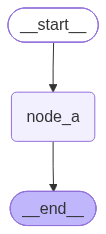

In [10]:
from IPython.display import Image, display

display(graph)

# 演示完节点缓存后，再看配置详情解释
首先缓存对于整个图结构，没有影响，缓存机制不会在图结构上显示出来，是额外配置的

缓存机制两个参数：
1. key_func： 一般不会改
    - 默认用经典结构，可以序列化，defalut_cache_key可以用
    - 只有节点输出有复杂对象，文件句柄，数据库，动态对象，要去自己定义，不然不一定能被key_function结构化序列化
2. ttl(time to live) 存活时间， 主要填这个

```python
def default_cache_key(*args: Any, **kwargs: Any) -> str | bytes:
    """Default cache key function that uses the arguments and keyword arguments to generate a hashable key."""
    import pickle

    # protocol 5 strikes a good balance between speed and size
    return pickle.dumps((_freeze(args), _freeze(kwargs)), protocol=5, fix_imports=False)
```
默认源代码如上，调用了腌咸菜包pickle，然后dumps腌制，腌制的时候传进来的内容和参数序列化缓存起来，不需要专门理解

一般填写ttl时间，单位是s， 

如果配置None，不会因为时间过期，不建议设置为永久缓存，内存一定会膨胀，资源一定越来越多缓存，不足
应该根据当前时间、远程API数据等合理场景配置ttl，或者把变量纳入缓存key的计算逻辑，项目里部署，1d，3d，7d都合理